# Permutation Problems – TSP with a Genetic Algorithm

This tutorial shows how to tackle the classic **Travelling Salesperson Problem (TSP)**
using the permutation operators included in `metaheuristic‑designer`.
We’ll build a Genetic Algorithm that evolves permutations of cities and
visualise the best route found.

Along the way you’ll see how to:
* load or create a TSP instance
* configure permutation‑specific crossover (`pmx`) and mutation (`swap`)
* assemble a GA strategy and run it
* plot the convergence and the optimal tour.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import metaheuristic_designer as mhd
from metaheuristic_designer.benchmarks import TSP
from metaheuristic_designer.initializers import PermInitializer
from metaheuristic_designer.operators import create_operator
from metaheuristic_designer.parent_selection import create_parent_selection
from metaheuristic_designer.survivor_selection import create_survivor_selection
from metaheuristic_designer.strategies import GA
from metaheuristic_designer.algorithms import Algorithm

## 1. Reproducibility

In [2]:
rng = mhd.check_random_state(42)

## 2. Create a small TSP instance

For the sake of visualisation we'll generate a random set of **10 cities**
on a 2‑D plane and compute the Euclidean distances.  In a real scenario you
would load an existing problem via `TSP.from_csv("path/to/problem.csv")`.

In [3]:
N_CITIES = 10
points = rng.uniform(0, 100, size=(N_CITIES, 2))
dist = np.sqrt(((points[:, None, :] - points[None, :, :]) ** 2).sum(axis=-1))

objfunc = TSP(dist, mode="min")

## 2.1 Full graph of the TSP instance
We draw the complete graph with edge labels showing the distances.

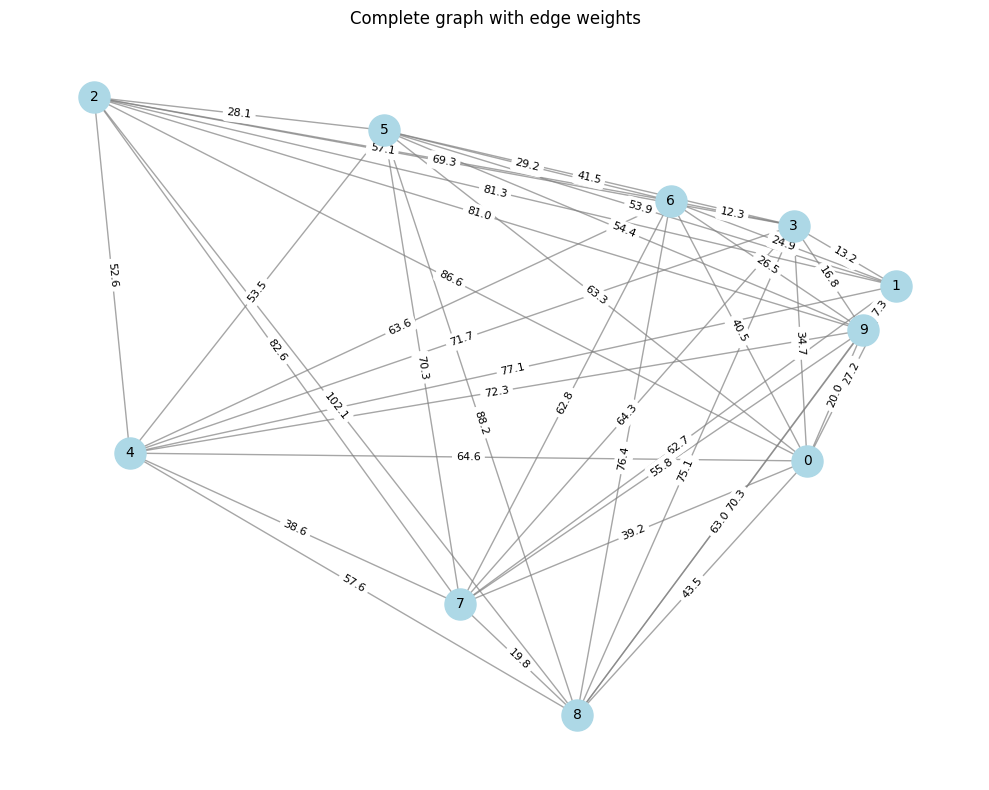

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
G_full = nx.Graph()
for i in range(N_CITIES):
    for j in range(i + 1, N_CITIES):
        G_full.add_edge(i, j, weight=round(dist[i, j], 1))

pos = {i: points[i] for i in range(N_CITIES)}
nx.draw_networkx_nodes(G_full, pos, node_color="lightblue", node_size=500, ax=ax)
nx.draw_networkx_labels(G_full, pos, font_size=10, ax=ax)
edges = nx.draw_networkx_edges(G_full, pos, edge_color="grey", width=1.0, alpha=0.7, ax=ax)
labels = nx.get_edge_attributes(G_full, 'weight')
nx.draw_networkx_edge_labels(G_full, pos, edge_labels=labels, font_size=8, ax=ax)
ax.set_title("Complete graph with edge weights")
ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Initializer – random permutations

A permutation individual is a sequence of city indices (0‑based).  We must
use `PermInitializer` which guarantees valid permutations without
repetitions.  We ask for a population of 100 individuals.

In [5]:
init = PermInitializer(N_CITIES, population_size=100, random_state=rng)

## 4. Genetic operators

We select two permutation operators from the `permutation` registry:
* **Crossover**: Partially Mapped Crossover (`pmx`) – preserves relative order.
* **Mutation**: Swap (`swap`) – exchanges two cities in the route.

Both are accessible via `create_operator("permutation.<name>", …)`.

The GA builder itself will handle the crossover probability (0.8) and
mutation probability (0.1) as usual.

In [6]:
crossover_op = create_operator("permutation.pmx", random_state=rng)
mutation_op  = create_operator("permutation.swap_mutation", N=2, random_state=rng)

## 4.1 Baseline random paths

Before running the GA, let's generate a few random permutations to see what
typical routes look like and their costs.

In [7]:
n_random = 4
random_tours = [init.generate_individual() for _ in range(n_random)]
random_lengths = [objfunc.objective(t.reshape(1, -1)).item() for t in random_tours]

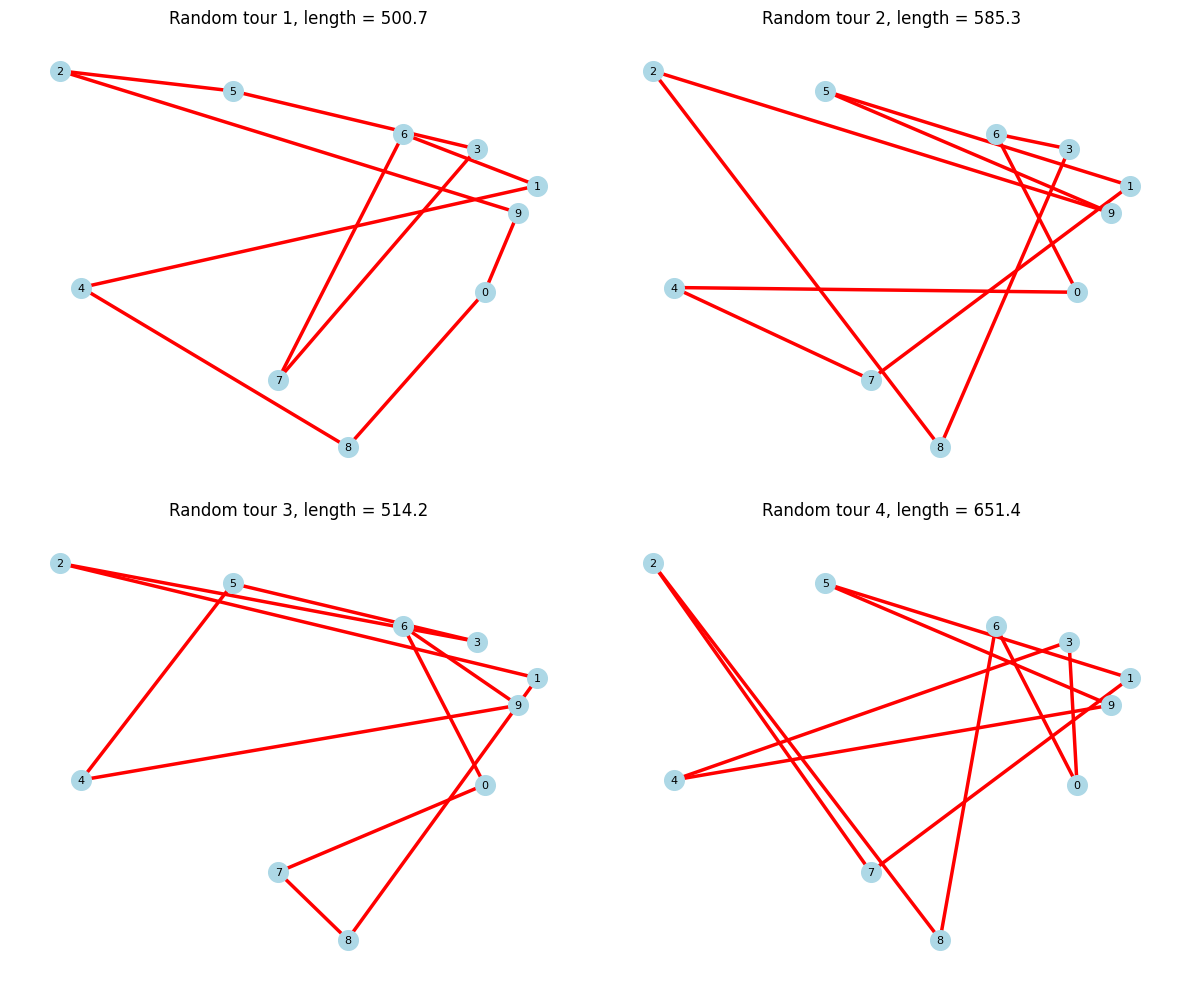

Random tour lengths: [500.71084380716667, 585.3304059476474, 514.2352831681143, 651.3503842929823]


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for idx, (tour, length) in enumerate(zip(random_tours, random_lengths)):
    ax = axes[idx]
    # Draw the edges of this tour
    tour_edges = [(tour[i], tour[i+1]) for i in range(N_CITIES - 1)] + [(tour[-1], tour[0])]
    nx.draw_networkx_nodes(G_full, pos, node_color="lightblue", node_size=200, ax=ax)
    nx.draw_networkx_edges(G_full, pos, edgelist=tour_edges, edge_color="red", width=2.5, ax=ax)
    nx.draw_networkx_labels(G_full, pos, font_size=8, ax=ax)
    ax.set_title(f"Random tour {idx+1}, length = {length:.1f}")
    ax.axis("off")
plt.tight_layout()
plt.show()
print("Random tour lengths:", random_lengths)

## 5. Parent & survivor selection

We use tournament parent selection and (μ+λ) survivor selection to keep the
best individuals from both parents and offspring.

In [9]:
parent_sel = create_parent_selection("tournament", amount=50, tournament_size=3, random_state=rng)
survivor_sel = create_survivor_selection("(mu+lambda)", random_state=rng)

## 6. Build the GA strategy

In [10]:
strategy = GA(
    initializer=init,
    mutation_op=mutation_op,
    crossover_op=crossover_op,
    parent_sel=parent_sel,
    survivor_sel=survivor_sel,
    mutation_prob=0.1,
    crossover_prob=0.8,
    random_state=rng,
)

## 7. Run the algorithm

We stop after 200 generations.  The `tqdm` reporter lets us watch the
progress.

In [11]:
algo = Algorithm(
    objfunc,
    strategy,
    max_iterations=200,
    stop_cond="max_iterations",
    reporter="tqdm",
)

population = algo.optimize()

  0%|          |   0% [00:00<?, ?it/s]

## 8. Results

The best solution is the optimal order of cities found.

In [12]:
solution, objective = population.best_solution()
print(f"Tour length: {objective:.2f}")
print("Best permutation (city order):", solution)

Tour length: 264.53
Best permutation (city order): [0 8 7 4 2 5 6 3 1 9]


## 9. Visualise the best tour

We draw the cities and the route with `networkx` and `matplotlib`.

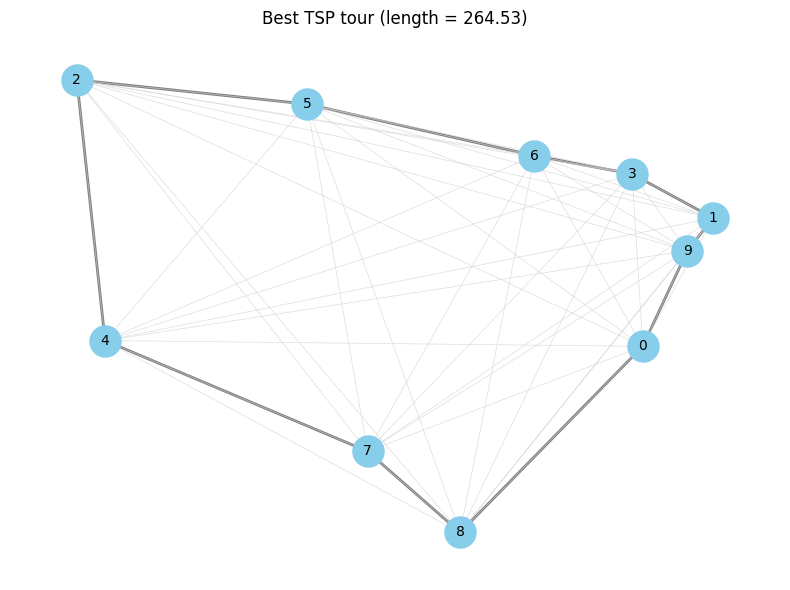

In [13]:
# Build a graph representing the tour
G = nx.Graph()
G.add_nodes_from(range(N_CITIES))
# Add edges of the best tour
for i in range(N_CITIES - 1):
    G.add_edge(solution[i], solution[i+1])
G.add_edge(solution[-1], solution[0])  # close the loop


# Position nodes according to the original 2‑D coordinates
pos = {i: points[i] for i in range(N_CITIES)}

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=500, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="grey", width=2, ax=ax)
nx.draw_networkx_edges(G_full, pos, edge_color="lightgrey", width=0.5, alpha=0.75, ax=ax)
# Highlight the first edge to indicate direction (optional)
ax.set_title(f"Best TSP tour (length = {objective:.2f})")
ax.axis("off")
plt.tight_layout()
plt.show()

## 10. Convergence plot

We can retrieve the history from the algorithm and plot the best objective
over generations.

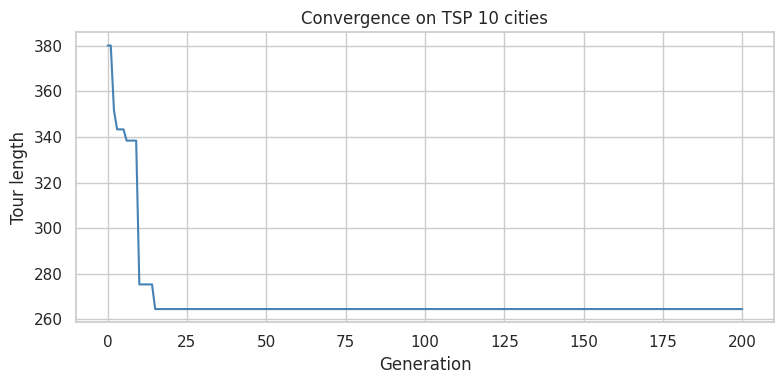

In [14]:
df = algo.history_tracker.to_pandas()
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=df, x="iteration", y="best_objective", ax=ax, color="steelblue")
ax.set_xlabel("Generation")
ax.set_ylabel("Tour length")
ax.set_title("Convergence on TSP 10 cities")
plt.tight_layout()
plt.show()